In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import xml.etree.ElementTree as ET

from skimage.feature import peak_local_max
from skimage.segmentation import watershed

images_path = r"BCCD\JPEGImages"
annotations_path = r"BCCD\Annotations"

all_images = sorted([f for f in os.listdir(images_path) if f.lower().endswith(".jpg")])
# test_images = all_images[260:285]
test_images = all_images[229:235]

demo_img_name = test_images[0] if len(test_images) > 0 else None

In [2]:
def get_actual_counts(img_name):
    """Read actual RBC and WBC counts from XML file"""
    xml_name = img_name.replace(".jpg", ".xml")
    xml_file = os.path.join(annotations_path, xml_name)

    counts = {"RBC": 0, "WBC": 0}

    if not os.path.exists(xml_file):
        return counts

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        label = obj.find("name").text
        if label in counts:
            counts[label] += 1

    return counts


def show_before_after(before, after, title_before="Before", title_after="After", cmap_after=None, figsize=(10, 4)):
    """Simple side-by-side preview for every processing step"""
    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)
    if before.ndim == 2:
        plt.imshow(before, cmap="gray")
    else:
        plt.imshow(before)
    plt.title(title_before)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    if cmap_after is not None:
        plt.imshow(after, cmap=cmap_after)
    else:
        if after.ndim == 2:
            plt.imshow(after, cmap="gray")
        else:
            plt.imshow(after)
    plt.title(title_after)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

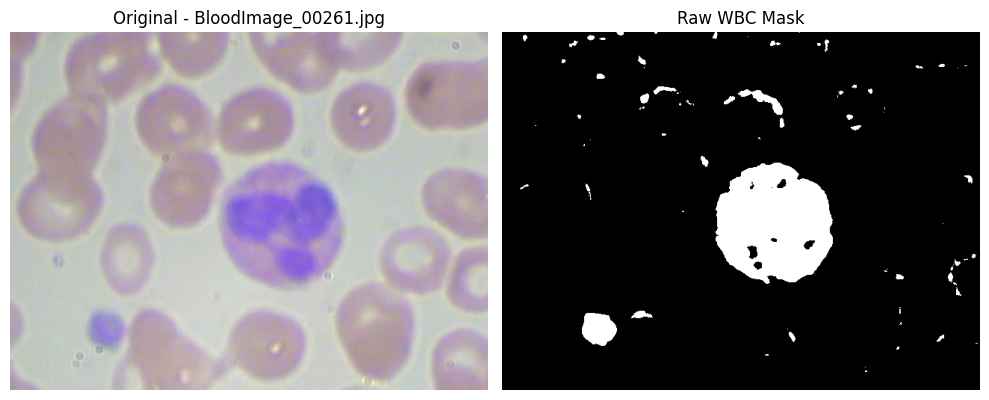

In [3]:
def get_wbc_mask(img):
    """Isolate the purple nucleus using HSV color space"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_purple = np.array([115, 50, 80])
    upper_purple = np.array([160, 255, 255])
    binary_mask = cv2.inRange(hsv, lower_purple, upper_purple)
    return binary_mask


# Demo on one image
demo_img = cv2.imread(os.path.join(images_path, demo_img_name))
demo_rgb = cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB)

raw_wbc_mask = get_wbc_mask(demo_img)

show_before_after(
    demo_rgb,
    raw_wbc_mask,
    title_before=f"Original - {demo_img_name}",
    title_after="Raw WBC Mask",
    cmap_after="gray"
)

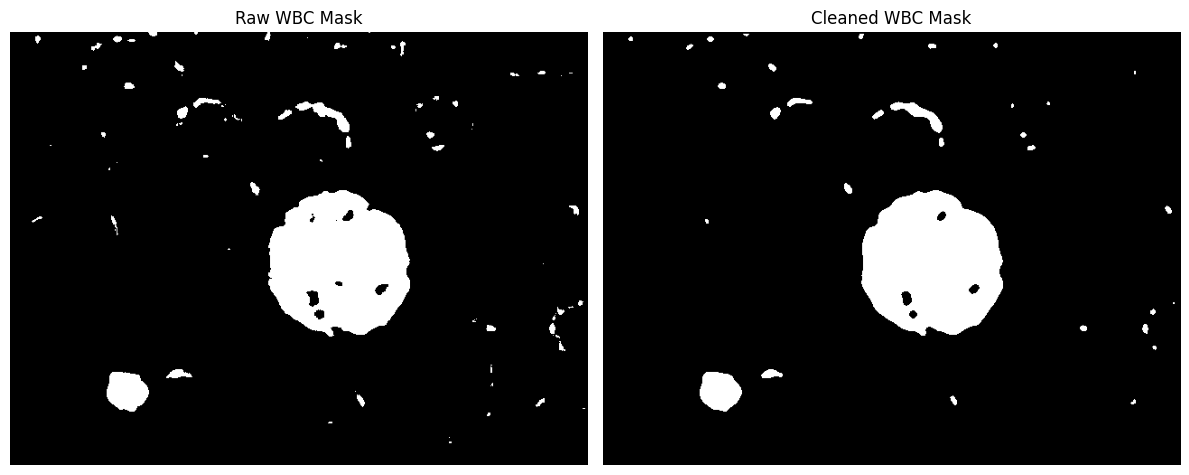

In [4]:
import numpy as np
import cv2

def manual_median_blur(mask, size=7):
    # Get image dimensions
    h, w = mask.shape
    offset = size // 2
    # Create empty image for output
    result = np.zeros((h, w), dtype=np.uint8)
    
    # Loop through every pixel (Manual implementation)
    for y in range(offset, h - offset):
        for x in range(offset, w - offset):
            # Extract the local neighborhood (window)
            window = mask[y-offset:y+offset+1, x-offset:x+offset+1]
            # Set the pixel to the median value of the window
            result[y, x] = np.median(window)
            
    return result

def clean_wbc_noise(binary_mask):
    # Step 1: Remove small holes using closing
    kernel = np.ones((5, 5), np.uint8)
    mask_closed = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    
    # Step 2: Custom median blur to remove noise
    cleaned_mask = manual_median_blur(mask_closed, 7)
    
    return cleaned_mask

# Apply the manual cleaning
cleaned_wbc_mask = clean_wbc_noise(raw_wbc_mask)

# Show results
# show_before_after(
#     raw_wbc_mask,
#     cleaned_wbc_mask,
#     title_before="Raw WBC Mask",
#     title_after="Cleaned WBC Mask",
#     cmap_after="gray"
# )

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(raw_wbc_mask, cmap='gray')
axes[0].set_title("Raw WBC Mask")
axes[0].axis('off') # Hide axes for cleaner look

axes[1].imshow(cleaned_wbc_mask, cmap='gray')
axes[1].set_title("Cleaned WBC Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# def clean_wbc_noise(binary_mask):
#     """Clean the mask noise using morphological operations and median blur"""
#     kernel = np.ones((5, 5), np.uint8)
#     mask_closed = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
#     cleaned_mask = cv2.medianBlur(mask_closed, 7)
#     return cleaned_mask


# cleaned_wbc_mask = clean_wbc_noise(raw_wbc_mask)

# show_before_after(
#     raw_wbc_mask,
#     cleaned_wbc_mask,
#     title_before="Raw WBC Mask",
#     title_after="Cleaned WBC Mask",
#     cmap_after="gray"
# )

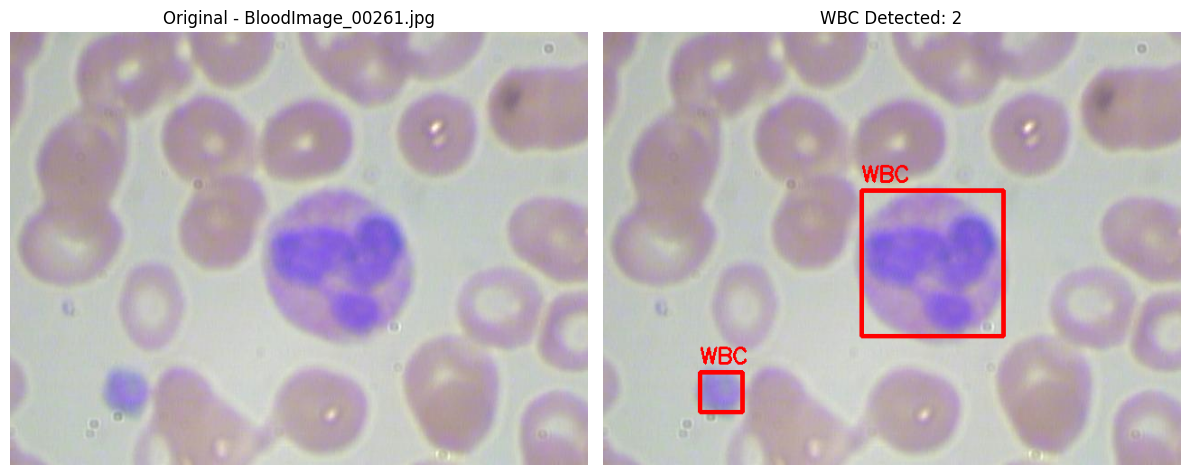

In [6]:
def extract_wbc_contours(cleaned_mask, min_wbc_area=1000):
    """Extract contours and filter based on minimum area"""
    contours, _ = cv2.findContours(
        cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    wbc_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > min_wbc_area:
            wbc_contours.append(cnt)
    return wbc_contours


def draw_wbcs(img_rgb, wbc_contours):
    """Draw bounding boxes and labels around detected WBCs"""
    img_out = img_rgb.copy()
    for cnt in wbc_contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (255, 0, 0), 3)
        cv2.putText(
            img_out, "WBC", (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2
        )
    return img_out


wbc_contours = extract_wbc_contours(cleaned_wbc_mask)
wbc_marked = draw_wbcs(demo_rgb, wbc_contours)

# show_before_after(
#     demo_rgb,
#     wbc_marked,
#     title_before=f"Original - {demo_img_name}",
#     title_after=f"WBC Detected: {len(wbc_contours)}"
# )


plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.imshow(demo_rgb)
plt.title(f"Original - {demo_img_name}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wbc_marked)
plt.title(f"WBC Detected: {len(wbc_contours)}")
plt.axis('off')

plt.tight_layout()
plt.show()

preprocessing for extract RBCs

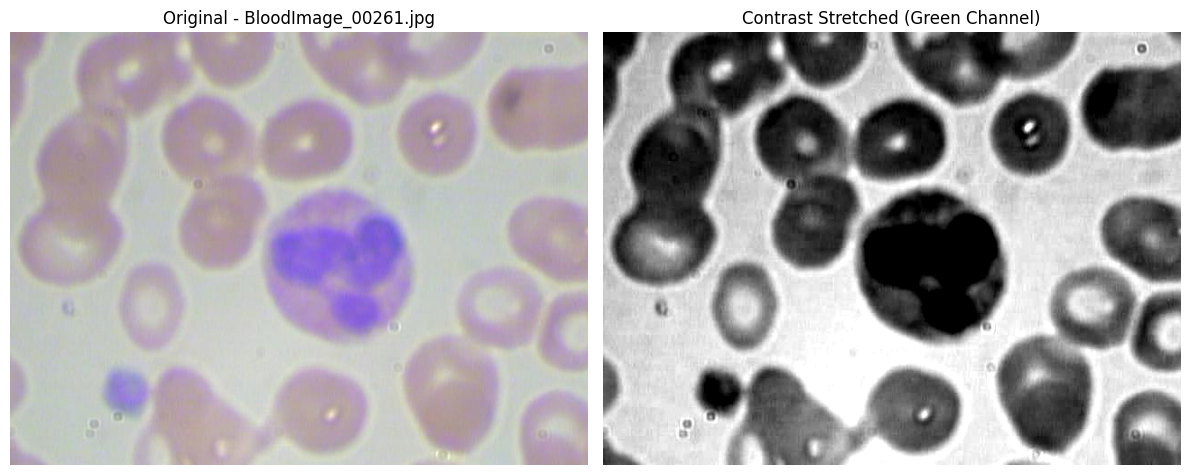

In [7]:
def contrast_stretching(img):
    """Extract green channel and apply contrast stretching"""
    green_channel = img[:, :, 1]

    r_min, r_max = np.percentile(green_channel, (5, 95))
    stretched = 255.0 * (green_channel - r_min) / (r_max - r_min)
    stretched = np.clip(stretched, 0, 255).astype(np.uint8)

    return stretched


stretched_demo = contrast_stretching(demo_img)

# show_before_after(
#     demo_rgb,
#     stretched_demo,
#     title_before=f"Original - {demo_img_name}",
#     title_after="Contrast Stretched (Green Channel)",
#     cmap_after="gray"
# )


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(demo_rgb)
axes[0].set_title(f"Original - {demo_img_name}")
axes[0].axis('off')

axes[1].imshow(stretched_demo, cmap='gray')
axes[1].set_title("Contrast Stretched (Green Channel)")
axes[1].axis('off')


plt.tight_layout()
plt.show()

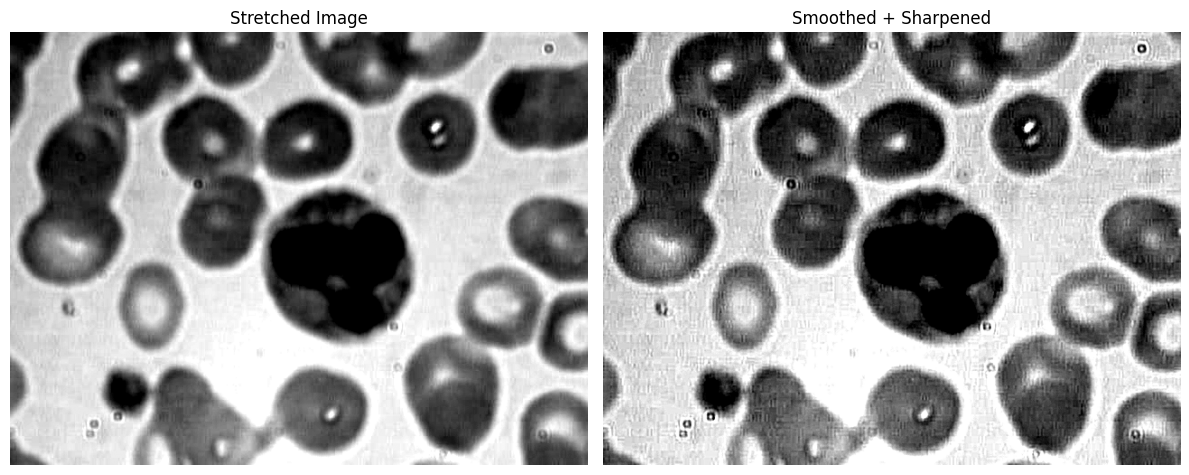

In [8]:
def apply_smoothing_and_sharpening(stretched_img):
    """Apply weighted average smoothing and Laplacian sharpening"""
    weighted_average_kernel = (
        np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16.0
    )
    smoothed = cv2.filter2D(stretched_img, -1, weighted_average_kernel)

    laplacian_kernel = np.array(
        [[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]], dtype=np.float32
    )
    sharpened = cv2.filter2D(smoothed, -1, laplacian_kernel)

    return sharpened


sharpened_demo = apply_smoothing_and_sharpening(stretched_demo)

# show_before_after(
#     stretched_demo,
#     sharpened_demo,
#     title_before="Stretched Image",
#     title_after="Smoothed + Sharpened",
#     cmap_after="gray"
# )


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(stretched_demo,cmap='gray')
axes[0].set_title(f"Stretched Image")
axes[0].axis('off')

axes[1].imshow(sharpened_demo, cmap='gray')
axes[1].set_title("Smoothed + Sharpened")
axes[1].axis('off')


plt.tight_layout()
plt.show()

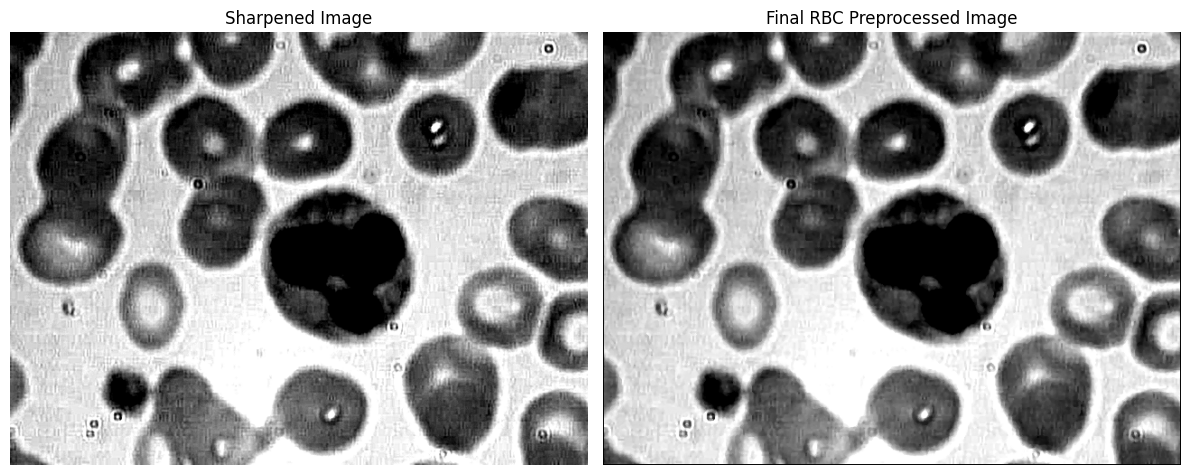

In [9]:
# def finalize_rbc_preprocessing(sharpened_img):
#     """Apply median filter to remove final noise artifacts"""
#     cleaned_rbc_img = cv2.medianBlur(sharpened_img, 3)
#     return cleaned_rbc_img


# final_rbc_demo = finalize_rbc_preprocessing(sharpened_demo)

# show_before_after(
#     sharpened_demo,
#     final_rbc_demo,
#     title_before="Sharpened Image",
#     title_after="Final RBC Preprocessed Image",
#     cmap_after="gray"
# )



def finalize_rbc_preprocessing(sharpened_img):
    # Get image dimensions
    h, w = sharpened_img.shape
    # Create an empty array for the output
    cleaned_rbc_img = np.zeros((h, w), dtype=np.uint8)
    
    # Manual 3x3 Median Filter
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            # 1. Extract the 3x3 neighborhood
            window = sharpened_img[i-1:i+2, j-1:j+2]
            
            # 2. Sort values and pick the middle one (Median)
            cleaned_rbc_img[i, j] = np.median(window)
            
    return cleaned_rbc_img

final_rbc_demo=finalize_rbc_preprocessing(sharpened_demo)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(sharpened_demo, cmap='gray')
axes[0].set_title(f"Sharpened Image")
axes[0].axis('off')

axes[1].imshow(final_rbc_demo, cmap='gray')
axes[1].set_title("Final RBC Preprocessed Image")
axes[1].axis('off')


plt.tight_layout()
plt.show()

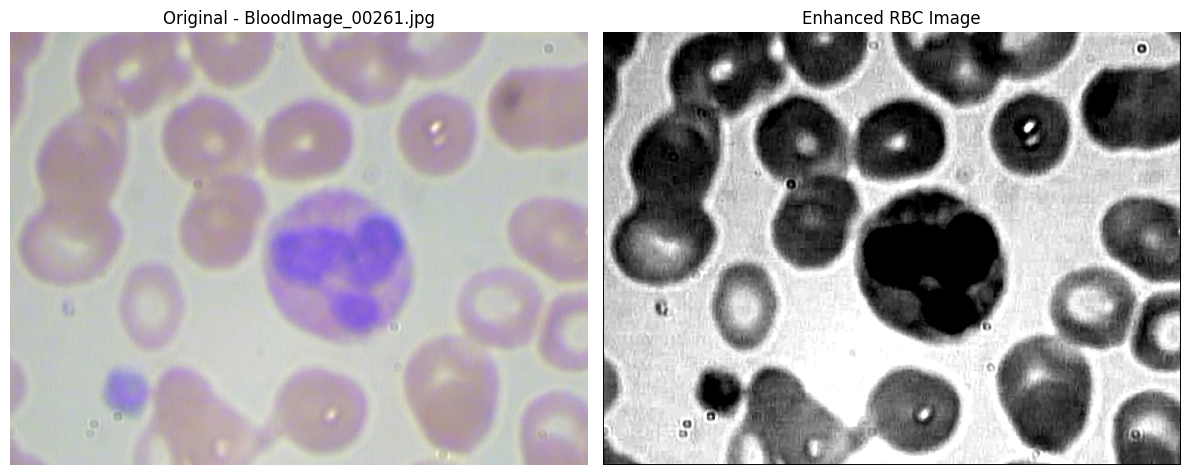

In [10]:
def enhance_rbcs(img):
    """Main wrapper for RBC preprocessing steps"""
    stretched = contrast_stretching(img)
    sharpened = apply_smoothing_and_sharpening(stretched)
    cleaned_rbc_img = finalize_rbc_preprocessing(sharpened)
    return cleaned_rbc_img


enhanced_demo = enhance_rbcs(demo_img)

# show_before_after(
#     demo_rgb,
#     enhanced_demo,
#     title_before=f"Original - {demo_img_name}",
#     title_after="Enhanced RBC Image",
#     cmap_after="gray"
# )

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(demo_rgb)
axes[0].set_title(f"Original - {demo_img_name}")
axes[0].axis('off')

axes[1].imshow(enhanced_demo, cmap='gray')
axes[1].set_title("Enhanced RBC Image")
axes[1].axis('off')


plt.tight_layout()
plt.show()

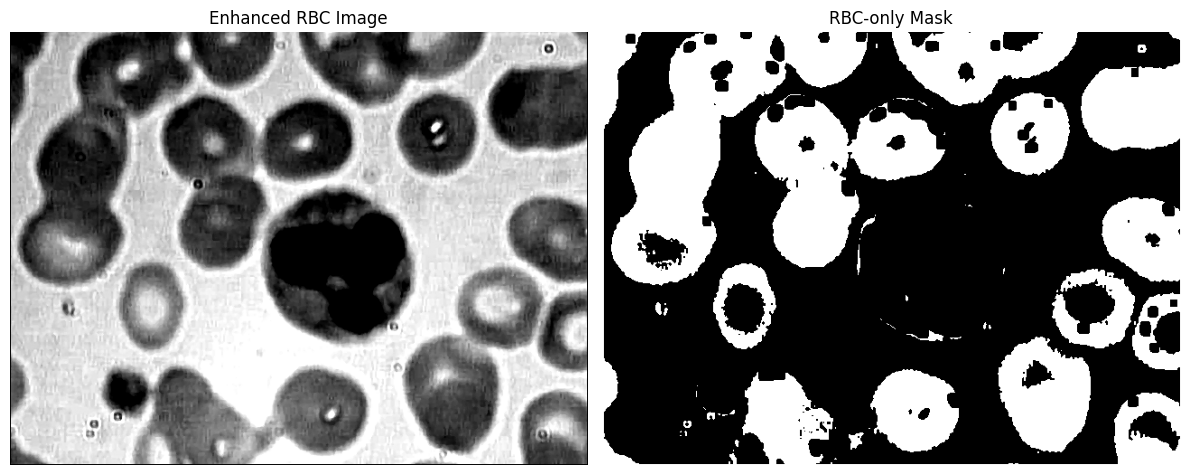

In [11]:
def get_rbc_mask_v3(enhanced_img, wbc_mask):
    """
    Generate the RBC mask by removing WBC areas from the enhanced image.
    """
    _, binary_mask = cv2.threshold(
        enhanced_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel_dilate = np.ones((7, 7), np.uint8)
    wbc_mask_dilated = cv2.dilate(wbc_mask, kernel_dilate, iterations=1)

    wbc_mask_inv = cv2.bitwise_not(wbc_mask_dilated)
    rbc_only_mask = cv2.bitwise_and(binary_mask, wbc_mask_inv)

    return rbc_only_mask


rbc_mask_demo = get_rbc_mask_v3(enhanced_demo, cleaned_wbc_mask)

# show_before_after(
#     enhanced_demo,
#     rbc_mask_demo,
#     title_before="Enhanced RBC Image",
#     title_after="RBC-only Mask",
#     cmap_after="gray"
# )

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(enhanced_demo, cmap='gray')
axes[0].set_title(f"Enhanced RBC Image")
axes[0].axis('off')

axes[1].imshow(rbc_mask_demo, cmap='gray')
axes[1].set_title("RBC-only Mask")
axes[1].axis('off')


plt.tight_layout()
plt.show()



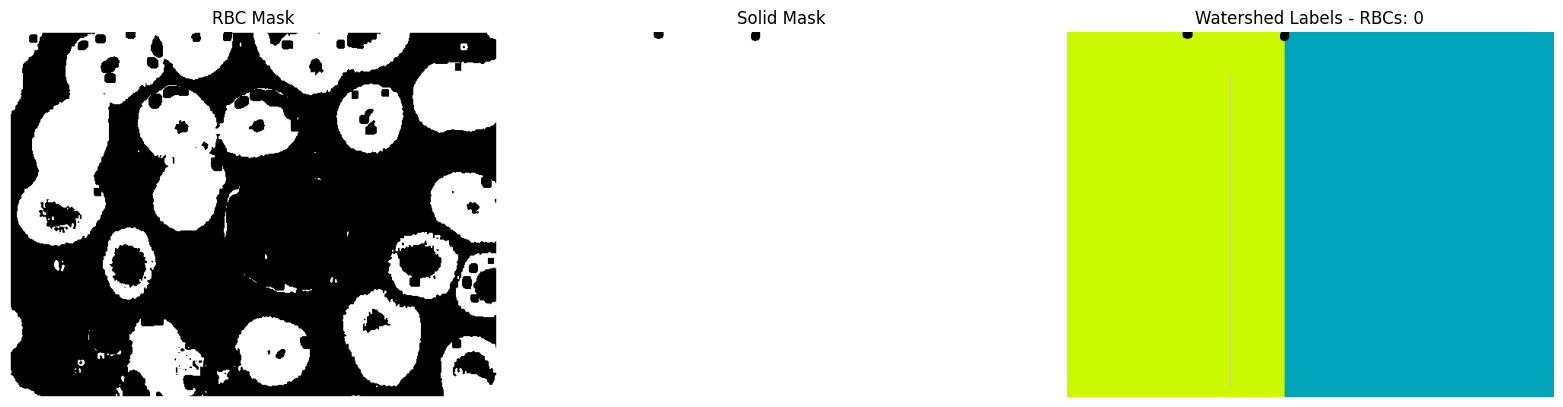

In [12]:
def clean_and_count_watershed_balanced(rbc_mask, min_distance=12, min_area=1500, max_area=25000):
    """
    Apply balanced Watershed segmentation to separate and count RBCs.
    """
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    closed_mask = cv2.morphologyEx(rbc_mask, cv2.MORPH_CLOSE, kernel_close)

    contours, hierarchy = cv2.findContours(closed_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    solid_mask = closed_mask.copy()
    if hierarchy is not None:
        for i in range(len(contours)):
            if hierarchy[0][i][3] != -1:
                cv2.drawContours(solid_mask, contours, i, 255, -1)

    dist_transform = cv2.distanceTransform(solid_mask, cv2.DIST_L2, 5)
    dist_blurred = cv2.GaussianBlur(dist_transform, (9, 9), 0)

    local_max_coords = peak_local_max(
        dist_blurred,
        min_distance=min_distance,
        threshold_abs=0.8,
        labels=solid_mask
    )

    markers = np.zeros(solid_mask.shape, dtype=np.int32)
    for i, coord in enumerate(local_max_coords):
        markers[coord[0], coord[1]] = i + 1

    labels = watershed(-dist_blurred, markers, mask=solid_mask)

    bboxes = []
    for label_id in np.unique(labels):
        if label_id == 0:
            continue

        cell_mask = np.uint8(labels == label_id) * 255
        cnts, _ = cv2.findContours(cell_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if cnts:
            cnt = max(cnts, key=cv2.contourArea)
            area = cv2.contourArea(cnt)

            if min_area < area < max_area:
                x, y, w, h = cv2.boundingRect(cnt)
                bboxes.append((x, y, w, h))

    return labels, bboxes, solid_mask


labels_demo, bboxes_demo, solid_mask_demo = clean_and_count_watershed_balanced(rbc_mask_demo)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.imshow(rbc_mask_demo, cmap="gray")
plt.title("RBC Mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(solid_mask_demo, cmap="gray")
plt.title("Solid Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(labels_demo, cmap="nipy_spectral")
plt.title(f"Watershed Labels - RBCs: {len(bboxes_demo)}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Manual Ground Truth (Custom Counts by Team)
# ============================================================
# Note: The original BCCD XML annotations contain inaccuracies
# (missing cells, incorrect labels). To get a fair accuracy
# evaluation, we manually counted RBCs and WBCs in 10 test images
# and use these counts as our reliable ground truth.
# ============================================================

# TODO: Fill in the image names you selected and the manual counts.
# Format: "image_name.jpg": {"RBC": <count>, "WBC": <count>}

manual_ground_truth = {
    "BloodImage_00260.jpg": {"RBC": 25,"WBC": 1},
    "BloodImage_00261.jpg": {"RBC": 20,"WBC": 1},
    "BloodImage_00262.jpg": {"RBC": 26, "WBC": 1},
    "BloodImage_00263.jpg": {"RBC": 25, "WBC": 1},
    "BloodImage_00264.jpg": {"RBC": 28, "WBC": 1},
    "BloodImage_00265.jpg": {"RBC": 22, "WBC": 1},
    "BloodImage_00266.jpg": {"RBC": 20, "WBC": 1},
    "BloodImage_00267.jpg": {"RBC": 26, "WBC": 1},
    "BloodImage_00268.jpg": {"RBC": 22, "WBC": 1},
    "BloodImage_00269.jpg": {"RBC": 23, "WBC": 1},
}

# Use only the manually counted images for evaluation
test_images = list(manual_ground_truth.keys())


def get_actual_counts(img_name):
    """
    Return manual ground truth counts if available,
    otherwise fall back to XML annotations.
    """
    if img_name in manual_ground_truth:
        return manual_ground_truth[img_name]

    # Fallback to XML (for images not manually counted)
    xml_name = img_name.replace(".jpg", ".xml")
    xml_file = os.path.join(annotations_path, xml_name)
    counts = {"RBC": 0, "WBC": 0}

    if not os.path.exists(xml_file):
        return counts

    tree = ET.parse(xml_file)
    root = tree.getroot()
    for obj in root.findall("object"):
        label = obj.find("name").text
        if label in counts:
            counts[label] += 1
    return counts


print(f"Loaded manual ground truth for {len(manual_ground_truth)} images")
print(f"Test images to evaluate: {len(test_images)}")


Loaded manual ground truth for 10 images
Test images to evaluate: 10


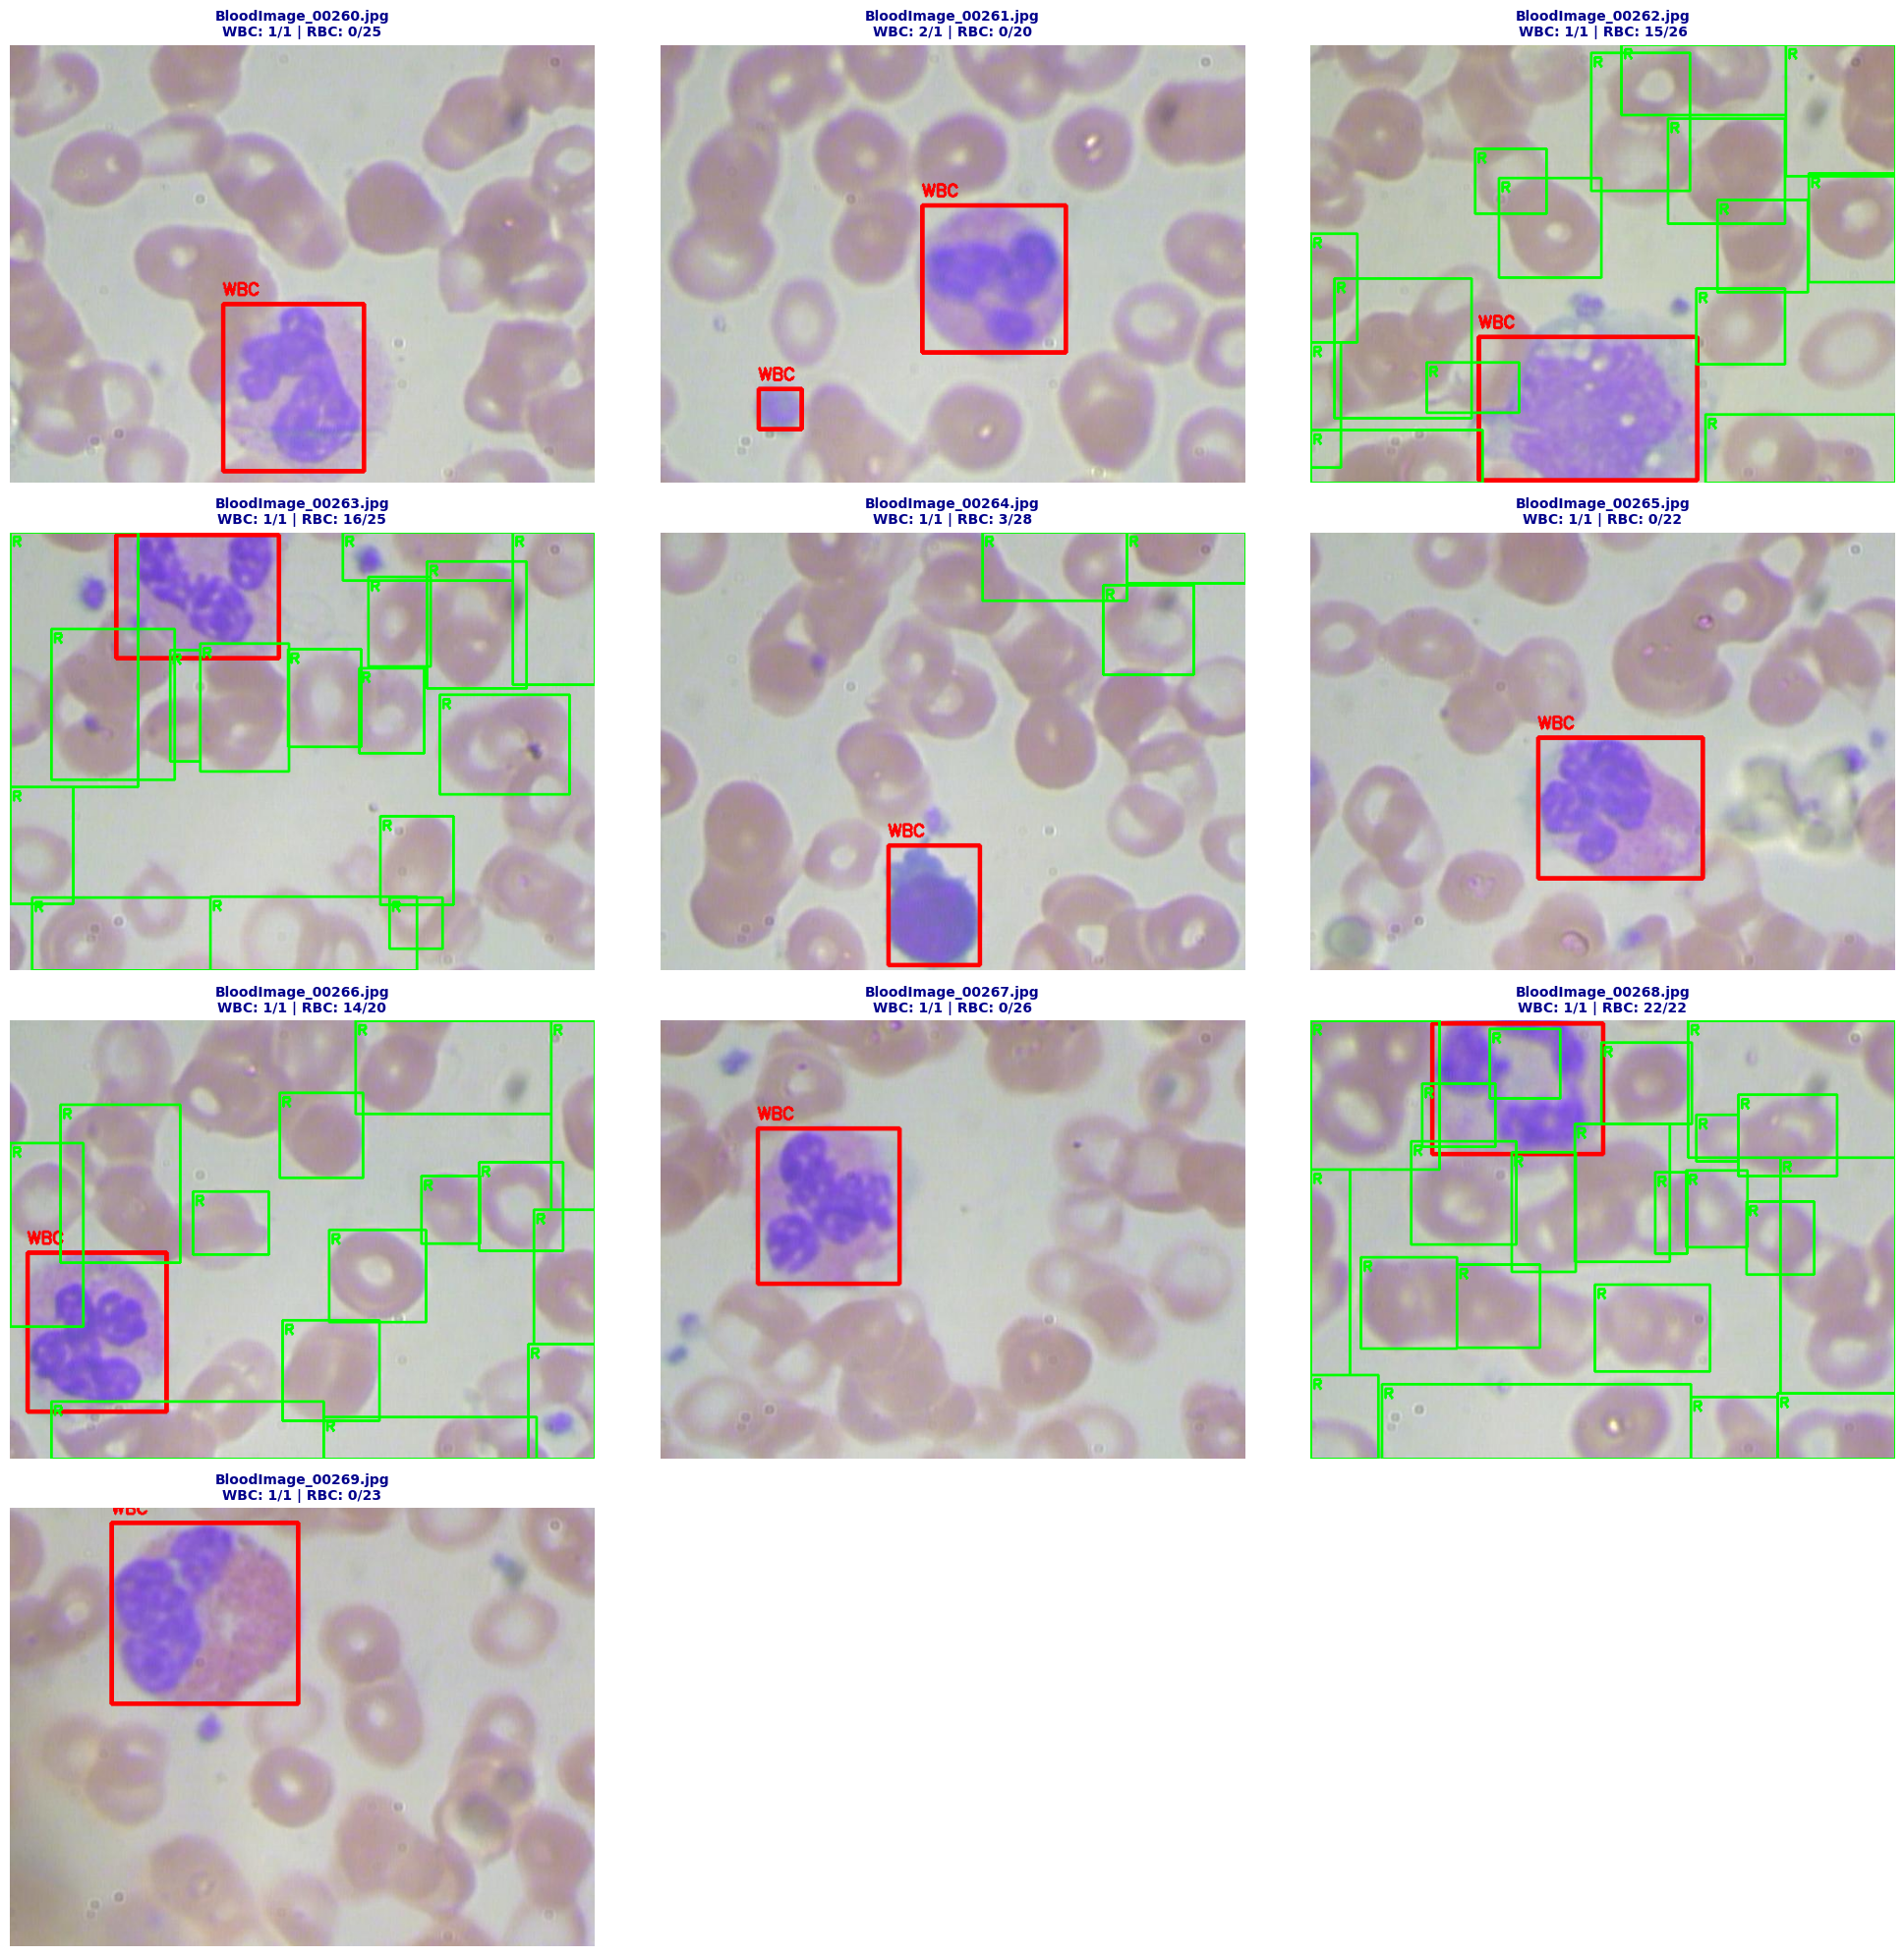

In [14]:
cols = 3
num_test = len(test_images)
rows = (num_test + cols - 1) // cols

plt.figure(figsize=(20, 5 * rows))

for i, img_name in enumerate(test_images):
    img_path = os.path.join(images_path, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    actual_counts = get_actual_counts(img_name)

    raw_wbc = get_wbc_mask(img)
    clean_wbc = clean_wbc_noise(raw_wbc)
    wbc_cnts = extract_wbc_contours(clean_wbc)

    enhanced_img = enhance_rbcs(img)
    rbc_mask = get_rbc_mask_v3(enhanced_img, clean_wbc)
    _, rbc_bboxes, solid_mask = clean_and_count_watershed_balanced(rbc_mask)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for cnt in wbc_cnts:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 3)
        cv2.putText(img_rgb, "WBC", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    for (x, y, w, h) in rbc_bboxes:
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img_rgb, "R", (x + 2, y + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_rgb)

    title_text = (
        f"{img_name}\n"
        f"WBC: {len(wbc_cnts)}/{actual_counts['WBC']} | "
        f"RBC: {len(rbc_bboxes)}/{actual_counts['RBC']}"
    )
    plt.title(title_text, fontsize=10, fontweight='bold', color='darkblue')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:

# Final Accuracy Evaluation

def count_accuracy(actual, detected):
    """
    Balanced counting accuracy for cell counting tasks.
    Handles both over-counting and under-counting fairly.
    """

    # Perfect case
    if actual == 0 and detected == 0:
        return 100.0

    # Avoid division by zero
    if actual == 0 or detected == 0:
        return 0.0

    # Balanced accuracy
    accuracy = (min(actual, detected) / max(actual, detected)) * 100

    return accuracy


results = []

for img_name in test_images:

    img_path = os.path.join(images_path, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # Ground Truth 
    actual_counts = get_actual_counts(img_name)

    actual_rbc = actual_counts["RBC"]
    actual_wbc = actual_counts["WBC"]

    # WBC Detection 
    raw_wbc = get_wbc_mask(img)
    clean_wbc = clean_wbc_noise(raw_wbc)

    wbc_cnts = extract_wbc_contours(clean_wbc)
    detected_wbc = len(wbc_cnts)

    #  RBC Detection 
    enhanced_img = enhance_rbcs(img)

    rbc_mask = get_rbc_mask_v3(enhanced_img, clean_wbc)

    _, rbc_bboxes, _ = clean_and_count_watershed_balanced(
        rbc_mask,
        min_distance=12,
        min_area=1500,
        max_area=25000
    )

    detected_rbc = len(rbc_bboxes)

    # Accuracy 
    rbc_accuracy = count_accuracy(actual_rbc, detected_rbc)
    wbc_accuracy = count_accuracy(actual_wbc, detected_wbc)

    # Save Results 
    results.append({
        "Image": img_name,

        "Actual_RBC": actual_rbc,
        "Detected_RBC": detected_rbc,
        "RBC_Accuracy_%": round(rbc_accuracy, 2),

        "Actual_WBC": actual_wbc,
        "Detected_WBC": detected_wbc,
        "WBC_Accuracy_%": round(wbc_accuracy, 2)
    })



In [16]:
# Results Table
results_df = pd.DataFrame(results)
display(results_df)

# Overall Accuracy

mean_rbc_accuracy = results_df["RBC_Accuracy_%"].mean()
mean_wbc_accuracy = results_df["WBC_Accuracy_%"].mean()

overall_accuracy = (mean_rbc_accuracy + mean_wbc_accuracy) / 2


print(f"\nMean RBC Accuracy   = {mean_rbc_accuracy:.2f}%")
print(f"Mean WBC Accuracy   = {mean_wbc_accuracy:.2f}%")
print(f"Overall Accuracy    = {overall_accuracy:.2f}%")

,Image,Actual_RBC,Detected_RBC,RBC_Accuracy_%,Actual_WBC,Detected_WBC,WBC_Accuracy_%
0,BloodImage_00260.jpg,25,0,0.00,1,1,100.0
1,BloodImage_00261.jpg,20,0,0.00,1,2,50.0
2,BloodImage_00262.jpg,26,15,57.69,1,1,100.0
3,BloodImage_00263.jpg,25,16,64.00,1,1,100.0
4,BloodImage_00264.jpg,28,3,10.71,1,1,100.0
5,BloodImage_00265.jpg,22,0,0.00,1,1,100.0
6,BloodImage_00266.jpg,20,14,70.00,1,1,100.0
7,BloodImage_00267.jpg,26,0,0.00,1,1,100.0
8,BloodImage_00268.jpg,22,22,100.00,1,1,100.0
9,BloodImage_00269.jpg,23,0,0.00,1,1,100.0



Mean RBC Accuracy   = 30.24%
Mean WBC Accuracy   = 95.00%
Overall Accuracy    = 62.62%


In [17]:
# Blood Cell Counting GUI (CustomTkinter)

import cv2
import numpy as np
import customtkinter as ctk
from PIL import Image
from tkinter import filedialog
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
import os

# ==========================================================
# 1. WBC Detection Functions
# ==========================================================

def get_wbc_mask(img):
    """Extract purple WBC nuclei using HSV thresholding"""

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower_purple = np.array([115, 50, 80])
    upper_purple = np.array([160, 255, 255])

    binary_mask = cv2.inRange(hsv, lower_purple, upper_purple)

    return binary_mask


def clean_wbc_noise(binary_mask):
    """Remove small noise from WBC mask"""

    kernel = np.ones((5, 5), np.uint8)

    mask_closed = cv2.morphologyEx(
        binary_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    cleaned_mask = cv2.medianBlur(mask_closed, 7)

    return cleaned_mask


def extract_wbc_contours(cleaned_mask, min_wbc_area=1000):
    """Extract valid WBC contours based on area"""

    contours, _ = cv2.findContours(
        cleaned_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    wbc_contours = []

    for cnt in contours:

        area = cv2.contourArea(cnt)

        if area > min_wbc_area:
            wbc_contours.append(cnt)

    return wbc_contours


# ==========================================================
# 2. RBC Enhancement Functions
# ==========================================================

def contrast_stretching(img):
    """Apply contrast stretching on green channel"""

    green_channel = img[:, :, 1]

    r_min, r_max = np.percentile(green_channel, (5, 95))

    stretched = 255.0 * (green_channel - r_min) / (r_max - r_min)

    stretched = np.clip(stretched, 0, 255).astype(np.uint8)

    return stretched


def apply_smoothing_and_sharpening(stretched_img):
    """Weighted smoothing + Laplacian sharpening"""

    weighted_average_kernel = (
        np.array(
            [[1, 2, 1],
             [2, 4, 2],
             [1, 2, 1]],
            dtype=np.float32
        ) / 16.0
    )

    smoothed = cv2.filter2D(
        stretched_img,
        -1,
        weighted_average_kernel
    )

    laplacian_kernel = np.array(
        [[-1, -1, -1],
         [-1,  9, -1],
         [-1, -1, -1]],
        dtype=np.float32
    )

    sharpened = cv2.filter2D(
        smoothed,
        -1,
        laplacian_kernel
    )

    return sharpened


def finalize_rbc_preprocessing(sharpened_img):
    """Final median filtering"""

    cleaned_rbc_img = cv2.medianBlur(sharpened_img, 3)

    return cleaned_rbc_img


def enhance_rbcs(img):
    """Complete RBC enhancement pipeline"""

    stretched = contrast_stretching(img)

    sharpened = apply_smoothing_and_sharpening(stretched)

    cleaned_rbc_img = finalize_rbc_preprocessing(sharpened)

    return cleaned_rbc_img


# ==========================================================
# 3. RBC Segmentation Functions
# ==========================================================

def get_rbc_mask_v3(enhanced_img, wbc_mask):
    """Generate RBC-only mask after removing WBC regions"""

    _, binary_mask = cv2.threshold(
        enhanced_img,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel_dilate = np.ones((7, 7), np.uint8)

    wbc_mask_dilated = cv2.dilate(
        wbc_mask,
        kernel_dilate,
        iterations=1
    )

    wbc_mask_inv = cv2.bitwise_not(wbc_mask_dilated)

    rbc_only_mask = cv2.bitwise_and(
        binary_mask,
        wbc_mask_inv
    )

    return rbc_only_mask


# ==========================================================
# 4. Watershed RBC Detection
# ==========================================================

def clean_and_count_watershed_balanced(
    rbc_mask,
    min_distance=12,
    min_area=1500,
    max_area=25000
):
    """Balanced watershed segmentation for RBC counting"""

    kernel_close = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (9, 9)
    )

    closed_mask = cv2.morphologyEx(
        rbc_mask,
        cv2.MORPH_CLOSE,
        kernel_close
    )

    contours, hierarchy = cv2.findContours(
        closed_mask,
        cv2.RETR_CCOMP,
        cv2.CHAIN_APPROX_SIMPLE
    )

    solid_mask = closed_mask.copy()

    if hierarchy is not None:

        for i in range(len(contours)):

            if hierarchy[0][i][3] != -1:
                cv2.drawContours(solid_mask, contours, i, 255, -1)

    dist_transform = cv2.distanceTransform(
        solid_mask,
        cv2.DIST_L2,
        5
    )

    dist_blurred = cv2.GaussianBlur(dist_transform, (9, 9), 0)

    local_max_coords = peak_local_max(
        dist_blurred,
        min_distance=min_distance,
        threshold_abs=0.8,
        labels=solid_mask
    )

    markers = np.zeros(solid_mask.shape, dtype=np.int32)

    for i, coord in enumerate(local_max_coords):
        markers[coord[0], coord[1]] = i + 1

    labels = watershed(-dist_blurred, markers, mask=solid_mask)

    bboxes = []

    for label_id in np.unique(labels):

        if label_id == 0:
            continue

        cell_mask = np.uint8(labels == label_id) * 255

        cnts, _ = cv2.findContours(
            cell_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if cnts:

            cnt = max(cnts, key=cv2.contourArea)

            area = cv2.contourArea(cnt)

            if min_area < area < max_area:

                x, y, w, h = cv2.boundingRect(cnt)

                bboxes.append((x, y, w, h))

    return labels, bboxes, solid_mask


# ==========================================================
# 5. GUI Configuration
# ==========================================================

ctk.set_appearance_mode("Dark")
ctk.set_default_color_theme("blue")


# ==========================================================
# 6. Main GUI Class
# ==========================================================

class BloodCellAnalyzerGUI(ctk.CTk):

    def __init__(self):

        super().__init__()

        self.title("Blood Cell Counting System")
        self.geometry("1200x780")

        self.grid_columnconfigure(1, weight=1)
        self.grid_rowconfigure(0, weight=1)

        self.image_cv = None

        # ==================================================
        # Sidebar
        # ==================================================

        self.sidebar = ctk.CTkFrame(
            self,
            width=260,
            corner_radius=0
        )

        self.sidebar.grid(row=0, column=0, sticky="nsew")

        self.title_label = ctk.CTkLabel(
            self.sidebar,
            text="HEMATOLOGY ANALYZER",
            font=("Arial", 22, "bold")
        )

        self.title_label.pack(pady=30)

        # Upload Button
        self.upload_button = ctk.CTkButton(
            self.sidebar,
            text="1. Upload Blood Image",
            command=self.upload_image,
            height=40
        )

        self.upload_button.pack(pady=10, padx=20, fill="x")

        # Run Button
        self.process_button = ctk.CTkButton(
            self.sidebar,
            text="2. Run Detection",
            command=self.process_image,
            fg_color="green",
            height=40,
            state="disabled"
        )

        self.process_button.pack(pady=10, padx=20, fill="x")

        # Reset Button
        self.reset_button = ctk.CTkButton(
            self.sidebar,
            text="Reset System",
            command=self.reset_system,
            fg_color="#8B0000",
            hover_color="#B22222",
            height=40
        )

        self.reset_button.pack(pady=10, padx=20, fill="x")

        # ==================================================
        # Results Panel
        # ==================================================

        self.results_frame = ctk.CTkFrame(
            self.sidebar,
            fg_color="#111111"
        )

        self.results_frame.pack(
            pady=40,
            padx=20,
            fill="x"
        )

        self.result_title = ctk.CTkLabel(
            self.results_frame,
            text="DETECTION RESULTS",
            font=("Arial", 18, "bold")
        )

        self.result_title.pack(pady=15)

        self.wbc_label = ctk.CTkLabel(
            self.results_frame,
            text="WBC Count : --",
            text_color="red",
            font=("Arial", 16, "bold")
        )

        self.wbc_label.pack(pady=10)

        self.rbc_label = ctk.CTkLabel(
            self.results_frame,
            text="RBC Count : --",
            text_color="lime",
            font=("Arial", 16, "bold")
        )

        self.rbc_label.pack(pady=10)

        # ==================================================
        # Image Display Area
        # ==================================================

        self.image_display = ctk.CTkLabel(
            self,
            text="Upload a microscopic blood image",
            fg_color="#1A1A1A",
            font=("Arial", 18)
        )

        self.image_display.grid(
            row=0,
            column=1,
            padx=20,
            pady=20,
            sticky="nsew"
        )

        # ==================================================
        # Status Bar
        # ==================================================

        self.status_bar = ctk.CTkLabel(
            self,
            text="Status : Ready",
            anchor="w",
            padx=20,
            height=35
        )

        self.status_bar.grid(
            row=1,
            column=0,
            columnspan=2,
            sticky="ew"
        )


    # ======================================================
    # Upload Image
    # ======================================================

    def upload_image(self):

        file_path = filedialog.askopenfilename(
            title="Select Blood Image",
            filetypes=[
                ("Image Files", "*.jpg *.png *.jpeg")
            ]
        )

        if file_path:

            self.image_cv = cv2.imread(file_path)

            self.show_image(self.image_cv)

            self.process_button.configure(state="normal")

            self.status_bar.configure(
                text=f"Status : Loaded {os.path.basename(file_path)}"
            )


    # ======================================================
    # Display Image on GUI
    # ======================================================

    def show_image(self, image):

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image_pil = Image.fromarray(image_rgb)

        image_pil.thumbnail((850, 650))

        ctk_image = ctk.CTkImage(
            light_image=image_pil,
            dark_image=image_pil,
            size=image_pil.size
        )

        self.image_display.configure(
            image=ctk_image,
            text=""
        )

        self.image_display.image = ctk_image


    # ======================================================
    # Reset System
    # ======================================================

    def reset_system(self):

        self.image_cv = None

        self.image_display.configure(
            image="",
            text="Upload a microscopic blood image"
        )

        self.image_display.image = None

        self.process_button.configure(state="disabled")

        self.wbc_label.configure(text="WBC Count : --")

        self.rbc_label.configure(text="RBC Count : --")

        self.status_bar.configure(text="Status : System Reset")


    # ======================================================
    # Main Processing Function
    # ======================================================

    def process_image(self):

        if self.image_cv is None:
            return

        self.status_bar.configure(text="Status : Processing Image...")

        self.update_idletasks()

        # ==================================================
        # WBC Detection
        # ==================================================

        raw_wbc_mask = get_wbc_mask(self.image_cv)

        clean_wbc_mask = clean_wbc_noise(raw_wbc_mask)

        wbc_contours = extract_wbc_contours(clean_wbc_mask)

        # ==================================================
        # RBC Detection
        # ==================================================

        enhanced_rbc_image = enhance_rbcs(self.image_cv)

        rbc_mask = get_rbc_mask_v3(
            enhanced_rbc_image,
            clean_wbc_mask
        )

        _, rbc_bboxes, _ = clean_and_count_watershed_balanced(rbc_mask)

        # ==================================================
        # Visualization
        # ==================================================

        output_image = self.image_cv.copy()

        # Draw WBCs in red
        for cnt in wbc_contours:

            x, y, w, h = cv2.boundingRect(cnt)

            cv2.rectangle(
                output_image,
                (x, y),
                (x + w, y + h),
                (0, 0, 255),
                3
            )

            cv2.putText(
                output_image,
                "WBC",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 0, 255),
                2
            )

        # Draw RBCs in green
        for (x, y, w, h) in rbc_bboxes:

            cv2.rectangle(
                output_image,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            cv2.putText(
                output_image,
                "R",
                (x + 2, y + 15),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

        # ==================================================
        # Update GUI
        # ==================================================

        self.show_image(output_image)

        self.wbc_label.configure(
            text=f"WBC Count : {len(wbc_contours)}"
        )

        self.rbc_label.configure(
            text=f"RBC Count : {len(rbc_bboxes)}"
        )

        self.status_bar.configure(
            text="Status : Detection Completed Successfully"
        )


# ==========================================================
# 7. Run Application
# ==========================================================

if __name__ == "__main__":

    app = BloodCellAnalyzerGUI()

    app.mainloop()





In [18]:
# pip install customtkinter pillow scikit-image opencv-python